In [55]:
import xarray as xr 
import cartopy.crs as ccrs 
import numpy as np
from tqdm.notebook import tqdm
import seaborn as sns
import seaborn.objects as so
import pandas as pd
import glob
import matplotlib.pyplot as plt
plt.style.use('robin')

In [2]:
from dask.distributed import LocalCluster,Client 

cluster= LocalCluster(n_workers=4, memory_limit='16GB')
client = Client(cluster)

# Attributing precipitation event to weather features in Western Norway

In [30]:
ds_ref = xr.open_dataset(f'/Data/gfi/scratch/kko033/attribution_varying_features/ea.for.198001.sfc.feature_info.tot_precip0.1.NH.nc')
files = glob.glob(f'/Data/gfi/scratch/kko033/attribution_varying_features/ea.for.*.sfc.feature_info.tot_precip0.1.NH.nc')
ds_regions= xr.open_dataarray('/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/aux/ERA5_rainfall_regions.nc').rename(lon='longitude',lat='latitude').interp_like(ds_ref)
ds_WN = ds_regions.where(ds_regions==14, drop=True)
ds_rain = xr.open_mfdataset('/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/indices/ERA5/pr/historical/*_region14.nc', combine='nested').tp.load()


In [4]:
all_ds = []
for file in tqdm(files):
    with xr.open_dataset(file) as ds_:
        all_ds.append(ds_.sel(longitude=ds_WN.longitude, latitude=ds_WN.latitude))
ds_features = xr.concat([xr.concat(all_ds[10*k:10*(k+1)], dim='time') for k in tqdm(range(506//10))], dim='time')
ds_features = ds_features.where(ds_features>0)

  0%|          | 0/506 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [6]:
df_features = ds_features.to_dataframe().iloc[:,:-2].reset_index()
# df_features df_features.time.dt.hour.map(lambda x: f"{x:02d}")
df_features['day'] = df_features.time.dt.round('D')
df_features['hour'] = df_features.time.dt.hour.map(lambda x: f"{x:02d}") +'H'

df_features['F'] = ('F_' + df_features['F'].fillna(0).astype(int).astype(str)).where(df_features['F'].notnull())
df_features['C'] = ('C_' + df_features['C'].fillna(0).astype(int).astype(str)).where(df_features['C'].notnull())
df_features['A'] = ('A_' + df_features['A'].fillna(0).astype(int).astype(str) + '_' + df_features['hour']).where(df_features['A'].notnull())
df_features['CAO'] = ('CAO_' + df_features['CAO'].fillna(0).astype(int).astype(str) ).where(df_features['CAO'].notnull())


In [7]:
df_features_time =df_features[['day','F','C','A','CAO']].set_index('day').stack().reset_index()
df_features_time.columns = ['day','feature_type','feature_id']


In [73]:
def make_series(series):
    series_out = pd.Series(np.sort(series.unique()))
    series_out = series_out.loc[series_out.notnull()]
    return series_out
def find_type(series):
    series_out = series.str.split('_', expand=True).iloc[:,0]
    series_out = series_out[series_out.notnull()]
    if len (series_out)==0:
        return 'NoFeature'
    series_out = '_'.join(series_out.unique())
    return series_out
df_feature_attributions = df_features_time.groupby('day').feature_id.apply(make_series).unstack()
df_feature_attributions['rain_type'] = df_feature_attributions.apply(find_type, axis=1)
df_feature_attributions = df_feature_attributions.reindex(ds_rain.to_series().index)
df_feature_attributions['rain_type'] = df_feature_attributions['rain_type'].fillna('NoFeature')
df_feature_attributions['daily_rain'] = ds_rain.to_series()

In [94]:
df_feature_attributions.to_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv")

/tmp/ipykernel_329827/2031471623.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = df_feature_attributions.groupby([pd.cut(df_feature_attributions.daily_rain, quantiles), 'rain_type']).daily_rain.count().rename('count').reset_index()


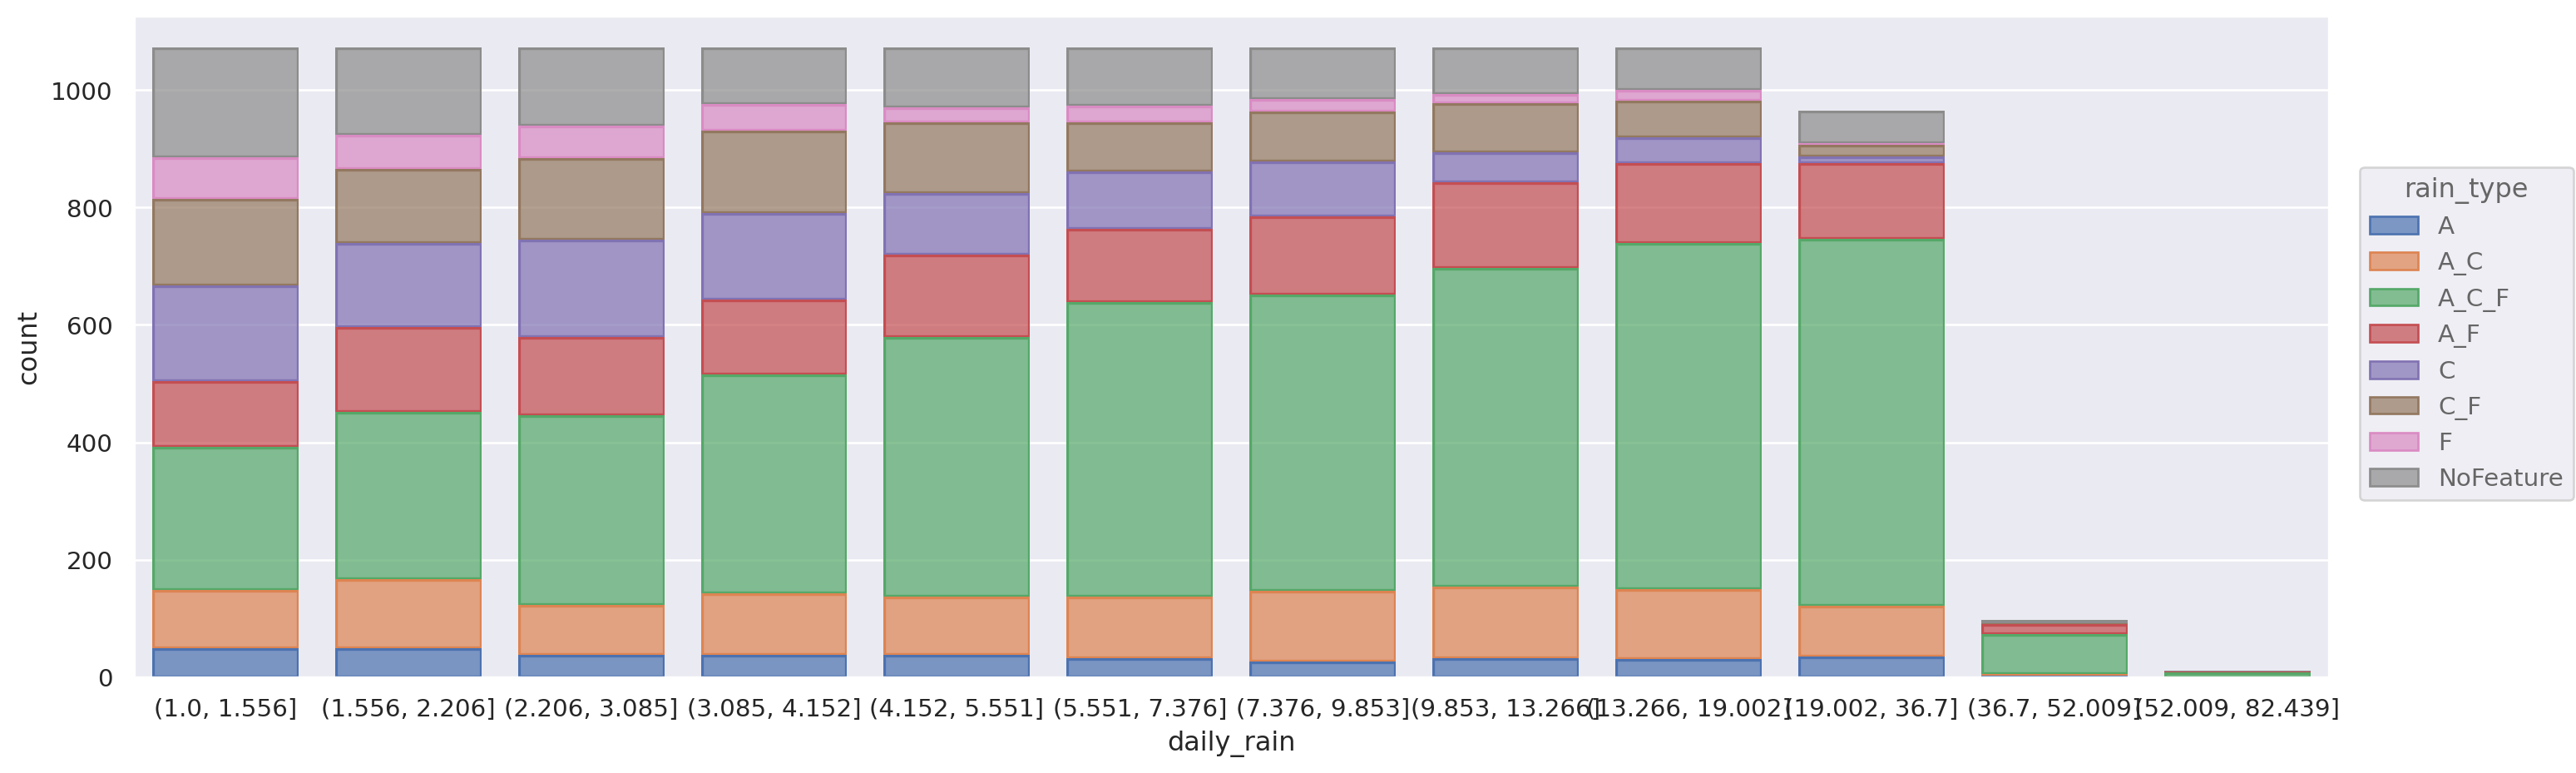

In [93]:
quantiles = df_feature_attributions.daily_rain.loc[df_feature_attributions.daily_rain>1].quantile(list(np.arange(0,1.,.1))+[.99,.999, 1])

df_ = df_feature_attributions.groupby([pd.cut(df_feature_attributions.daily_rain, quantiles), 'rain_type']).daily_rain.count().rename('count').reset_index()

(so.Plot(df_, x='daily_rain', y='count', color='rain_type')
    .add(so.Bar(), so.Stack(),)
    .layout(size=(15,5))
 
)
# df_

In [86]:
df_

,daily_rain,rain_type,cumul_rain
0,"(1.0, 1.556]",A,60.477798
1,"(1.0, 1.556]",A_C,126.019234
2,"(1.0, 1.556]",A_C_F,309.111068
3,"(1.0, 1.556]",A_F,142.493315
4,"(1.0, 1.556]",C,201.783074
...,...,...,...
75,"(19.002, 82.439]",A_F,4049.785619
76,"(19.002, 82.439]",C,277.981516
77,"(19.002, 82.439]",C_F,488.693048
78,"(19.002, 82.439]",F,70.621670


In [4]:
def select_area(ds):
    return ds.sel(longitude=ds_WN.longitude, latitude=ds_WN.latitude)
ds_features = xr.open_mfdataset(f'/Data/gfi/scratch/kko033/attribution_varying_features/ea.for.*.sfc.feature_info.tot_precip0.1.NH.nc', 
                                preprocess=select_area, parallel=True).load()




2025-07-01 10:44:21,350 - distributed.nanny - WARNING - Restarting worker
2025-07-01 10:44:21,366 - distributed.nanny - WARNING - Restarting worker
2025-07-01 10:44:21,384 - distributed.nanny - WARNING - Restarting worker
2025-07-01 10:44:21,404 - distributed.nanny - WARNING - Restarting worker
2025-07-01 10:44:24,013 - distributed.nanny - WARNING - Restarting worker
2025-07-01 10:44:24,017 - distributed.nanny - WARNING - Restarting worker
2025-07-01 10:44:24,337 - distributed.nanny - WARNING - Restarting worker
2025-07-01 10:44:24,341 - distributed.nanny - WARNING - Restarting worker
2025-07-01 10:44:26,528 - distributed.nanny - WARNING - Restarting worker
2025-07-01 10:44:26,730 - distributed.nanny - WARNING - Restarting worker
2025-07-01 10:44:27,028 - distributed.nanny - WARNING - Restarting worker
2025-07-01 10:44:27,116 - distributed.nanny - WARNING - Restarting worker
2025-07-01 10:44:29,218 - distributed.scheduler - ERROR - Task open_dataset-4fdbebfb-664c-4741-9893-6d9662727caf

KilledWorker: Attempted to run task 'open_dataset-4de94218-25ad-4587-b146-610ad7b26927' on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:42379. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

In [30]:
ds_features

<xarray.Dataset> Size: 63MB
Dimensions:    (time: 123200, latitude: 5, longitude: 5)
Coordinates:
  * time       (time) datetime64[ns] 986kB 1980-01-01 ... 2022-02-28T21:00:00
  * latitude   (latitude) float32 20B 62.0 61.5 61.0 60.5 60.0
  * longitude  (longitude) float32 20B 5.5 6.0 6.5 7.0 7.5
    pressure   float64 8B 850.0
    number     int64 8B 0
Data variables:
    F          (time, latitude, longitude) float32 12MB dask.array<chunksize=(124, 5, 5), meta=np.ndarray>
    C          (time, latitude, longitude) float32 12MB dask.array<chunksize=(124, 5, 5), meta=np.ndarray>
    A          (time, latitude, longitude) float32 12MB dask.array<chunksize=(124, 5, 5), meta=np.ndarray>
    CAO        (time, latitude, longitude) float64 25MB dask.array<chunksize=(83, 5, 5), meta=np.ndarray>

In [9]:
ds_attrs = xr.open_dataset('/Data/gfi/users/rogui7909/data/NN_outputs/rosendal/4conv_layer_attributions.nc')
time_attributions = ds_attrs.attribution_time

In [12]:
year=2001
ds = xr.open_mfdataset(f'/Data/gfi/scratch/kko033/attribution_varying_features/ea.for.{year}*.sfc.feature_info.tot_precip0.1.NH.nc')
ds

<xarray.Dataset> Size: 8GB
Dimensions:    (time: 2920, latitude: 181, longitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 23kB 2001-01-01 ... 2001-12-31T21:00:00
  * latitude   (latitude) float32 724B 90.0 89.5 89.0 88.5 ... 1.5 1.0 0.5 0.0
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
    pressure   float64 8B 850.0
Data variables:
    F          (time, latitude, longitude) float32 2GB dask.array<chunksize=(124, 91, 360), meta=np.ndarray>
    C          (time, latitude, longitude) float32 2GB dask.array<chunksize=(124, 91, 360), meta=np.ndarray>
    A          (time, latitude, longitude) float32 2GB dask.array<chunksize=(124, 91, 360), meta=np.ndarray>
    CAO        (time, latitude, longitude) float64 3GB dask.array<chunksize=(83, 61, 240), meta=np.ndarray>

In [ ]:
ds = xr.open_mfdataset(f'/Data/gfi/scratch/kko033/attribution_varying_features/ea.for.{year}*.sfc.feature_info.tot_precip0.1.NH.nc')
ds = ds.where(ds>0)

ds_regions= xr.open_dataarray('/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/aux/ERA5_rainfall_regions.nc').rename(lon='longitude',lat='latitude')
ds_rain = xr.open_mfdataset('/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/indices/ERA5/pr/historical/*_region14.nc', combine='nested').tp.load()
ds_regions = ds_regions.interp_like(ds, method='nearest').dropna('longitude', how='all').dropna('latitude', how='all')
ds_regions.loc[dict(latitude=slice(None, 61), longitude=slice(None,0))]=np.nan

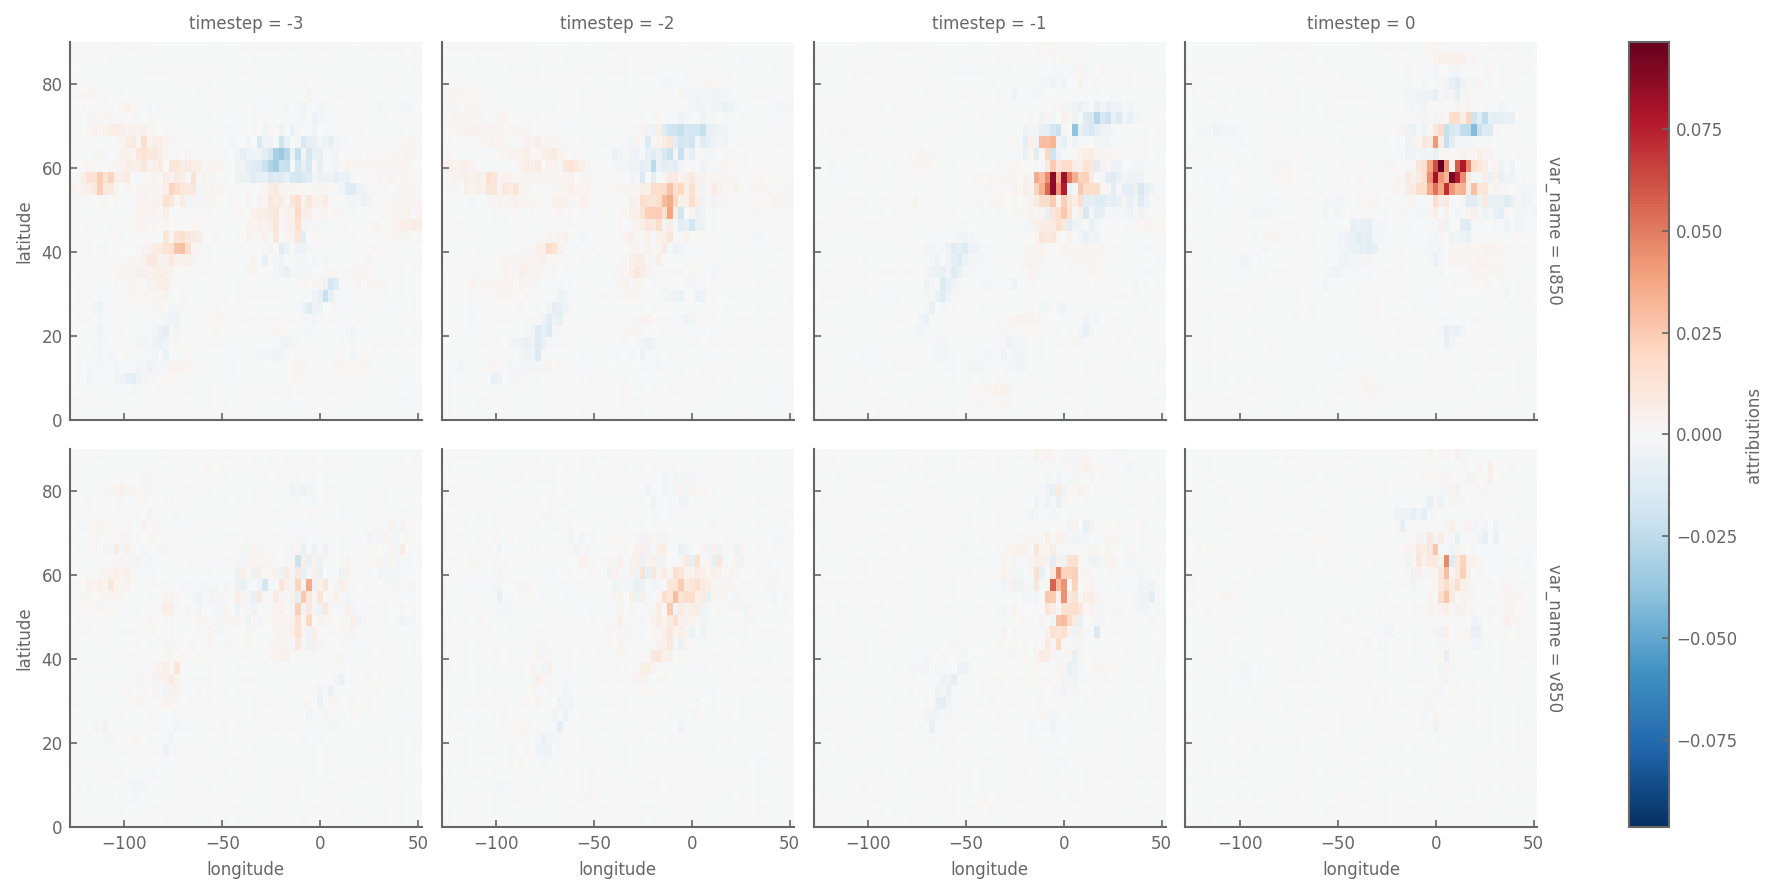

In [4]:
time = '2001-10-03'
year, month, day = time.split('-')

true_attrs = ds_attrs.sel(attribution_time=time).attributions.shift(timestep=-1).isel(timestep=range(4)).assign_coords(timestep=np.arange(-3,1))

sens = ds_attrs.sel(attribution_time=time).sensitivity.shift(timestep=-1).isel(timestep=range(4)).assign_coords(timestep=np.arange(-3,1))
fields = true_attrs/sens

true_attrs.plot(col='timestep', row='var_name')

In [7]:
ds_rain.sel(time=ds_attrs.attribution_time).to_series().sort_values().iloc[-10:]

attribution_time
2004-12-30    39.989291
1998-02-23    40.237907
2003-09-22    40.926514
2004-09-27    41.099065
2003-01-15    41.563038
2004-11-12    41.723074
1999-11-28    44.696763
2005-01-07    46.526950
1999-02-04    51.956167
1997-03-02    53.347126
Name: tp, dtype: float64

In [6]:
ds = xr.open_dataset(f'/Data/gfi/scratch/kko033/attribution_varying_features/ea.for.{year}{month}.sfc.feature_info.tot_precip0.1.NH.nc')
ds = ds.where(ds>0)

ds_regions= xr.open_dataarray('/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/aux/ERA5_rainfall_regions.nc').rename(lon='longitude',lat='latitude')
ds_rain = xr.open_mfdataset('/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/indices/ERA5/pr/historical/*_region14.nc', combine='nested').tp.load()
ds_regions = ds_regions.interp_like(ds, method='nearest').dropna('longitude', how='all').dropna('latitude', how='all')
ds_regions.loc[dict(latitude=slice(None, 61), longitude=slice(None,0))]=np.nan

In [432]:
region_number = 14
ds_extract = ds.where(ds_regions==region_number, drop=True)
df = ds_extract.to_dataframe()[['F','C','A','CAO']].stack().reset_index()
df.columns = ['time','latitiude','longitude','type_feature','feature_id']
df['features'] = df.type_feature + '_' + df.feature_id.astype(int).astype(str)
df=df.loc[df.feature_id !=0] 
df_features = df[['time','features']].groupby('time').value_counts().reset_index().set_index('time').features.reset_index()
features_per_time = df_features.groupby('time').features.apply(list).apply(lambda l:list(set(l))).apply(np.sort).apply(pd.Series)#.apply(pd.unique)
# df_features['day'] = df_features.time.dt.round('D')
# features_per_day = df_features.groupby('day').features.apply(list).apply(lambda l:list(set(l))).apply(np.sort).apply(pd.Series)#.apply(pd.unique)
# features_per_day
# df_features

In [433]:
features_per_time

,0,1,2
time,,,
2004-11-01 00:00:00,A_18,NaN,NaN
2004-11-01 03:00:00,F_2435,NaN,NaN
2004-11-02 09:00:00,A_20,NaN,NaN
2004-11-03 09:00:00,A_18,F_471,NaN
2004-11-03 12:00:00,A_20,F_471,NaN
...,...,...,...
2004-11-30 03:00:00,A_20,NaN,NaN
2004-11-30 12:00:00,C_532531,NaN,NaN
2004-11-30 15:00:00,C_532531,F_38161,NaN


# Test one time

In [408]:
import numpy as np

def haversine_np(lon1, lat1, lon2, lat2, radius=6371):
    """
    Compute the Haversine distance between two points or arrays of points using NumPy.

    Parameters:
        lon1, lat1: float or np.ndarray
            Longitude and latitude of the first point(s) in degrees.
        lon2, lat2: float or np.ndarray
            Longitude and latitude of the second point(s) in degrees.
        radius: float
            Radius of the Earth in kilometers (default is 6371 km).

    Returns:
        np.ndarray or float
            Distance in kilometers.
    """
    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return radius * c


In [451]:
ds_rain.sel(time=time)

<xarray.DataArray 'tp' ()> Size: 8B
array(41.72307433)
Coordinates:
    time     datetime64[ns] 8B 2004-11-12
    number   int64 8B 0
    mask_id  float64 8B 14.0

In [434]:

features_time= features_per_time.loc[time]
features_list = np.unique(features_time.stack().dropna().values)

cyclones_time = [int(k.split('_')[1]) for k in features_list if k.startswith('C_')]
fronts_time = [int(k.split('_')[1]) for k in features_list if k.startswith('F_')]
caos_time = [int(k.split('_')[1]) for k in features_list if k.startswith('CAO_')]
moistureaxis_time = [int(k.split('_')[1]) for k in features_list if k.startswith('A_')]

In [435]:
features_list

array(['A_16', 'A_19', 'A_20', 'A_21', 'C_531666', 'F_18'], dtype=object)

In [148]:
distances.min('cyclone_index').rename(day='time')

<xarray.DataArray (var_name: 2, latitude: 32, longitude: 64, time: 6)> Size: 197kB
array([[[[ 5143.9738102 ,  5762.80089432,  6849.03175984,
           8346.5375019 ,  9639.59308263, 11246.23436096],
         [ 4976.95824356,  5597.93103971,  6690.08198375,
           8179.6246655 ,  9456.40732878, 11084.68059283],
         [ 4820.95919044,  5442.10824626,  6537.41872782,
           8015.65154366,  9273.79138028, 10920.8951926 ],
         ...,
         [13614.56347709, 12597.73344573,  8526.19057374,
           8107.95892242,  7839.85810438,  7736.57423315],
         [13799.3230637 , 12770.99385039,  8699.34694155,
           8243.1708137 ,  7939.59474474,  7946.24307236],
         [13976.87624387, 12938.94870168,  8874.39511294,
           8381.56980496,  8043.58909026,  8089.22163974]],

        [[ 4885.27165379,  5501.62429183,  6582.67143254,
           8083.59071564,  9386.48741726, 10977.38769962],
         [ 4711.49024074,  5331.31136057,  6420.15125919,
           7914.97498941,  9203.0714955 , 10817.31904386],
         [ 4548.61934378,  5169.92180834,  6263.78191517,
           7749.11612923,  9020.0135367 , 10654.85678082],
...
         [ 5761.25030042,  4912.18131538,  3757.55275516,
           3030.72346023,  1941.66802953,  1687.50111826],
         [ 5775.69958459,  4928.86273073,  3779.85655248,
           3051.49142148,  1958.44632211,  1704.28374664],
         [ 5789.29723248,  4944.79232816,  3802.41458348,
           3072.74359117,  1976.08647225,  1721.9454447 ]],

        [[ 5280.41853537,  4493.9592303 ,  3807.29918653,
           3337.69930103,  2407.58139382,  2158.95439938],
         [ 5276.19178485,  4488.77267429,  3800.5394547 ,
           3330.80851253,  2402.21260321,  2153.71772498],
         [ 5272.29051228,  4483.87611933,  3793.96954945,
           3323.76298449,  2396.59237208,  2148.22528639],
         ...,
         [ 5525.20229088,  4706.69071259,  3852.10842237,
           3183.79370936,  2173.01469632,  1920.4717413 ],
         [ 5530.17354535,  4712.45467922,  3859.40134771,
           3190.42967102,  2178.0511814 ,  1925.426144  ],
         [ 5534.85685851,  4717.96796054,  3866.80367872,
           3197.25043639,  2183.37942617,  1930.67821893]]]])
Coordinates:
    timestep          int64 8B 0
  * var_name          (var_name) <U4 32B 'u850' 'v850'
  * latitude          (latitude) float64 256B 1.406 4.219 7.031 ... 85.78 88.59
  * longitude         (longitude) float64 512B -126.6 -123.8 ... 47.81 50.62
    attribution_time  datetime64[ns] 8B 1999-11-28
    mask_id           int64 8B 14
  * time              (time) datetime64[ns] 48B 1999-11-23 ... 1999-11-28

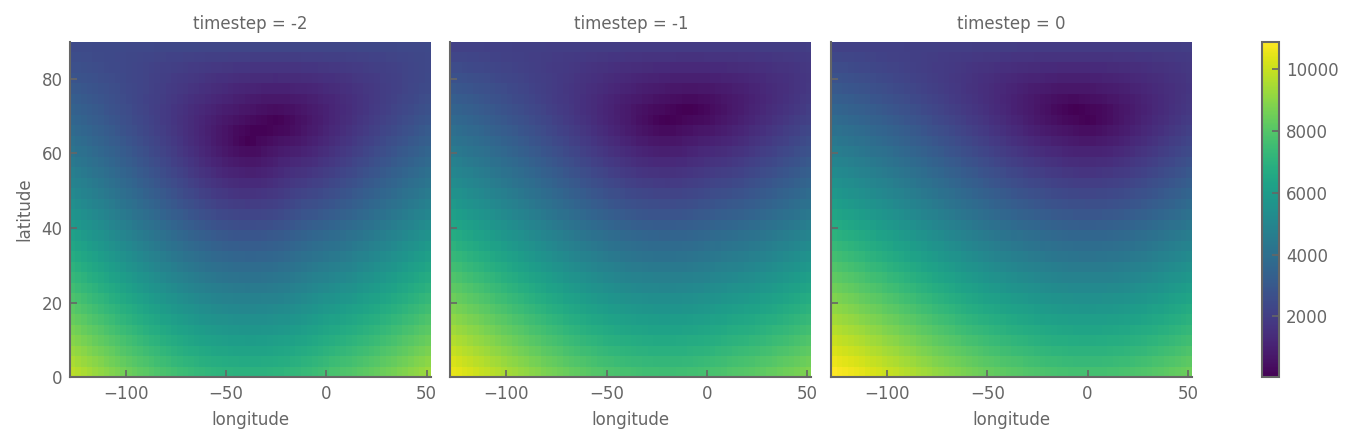

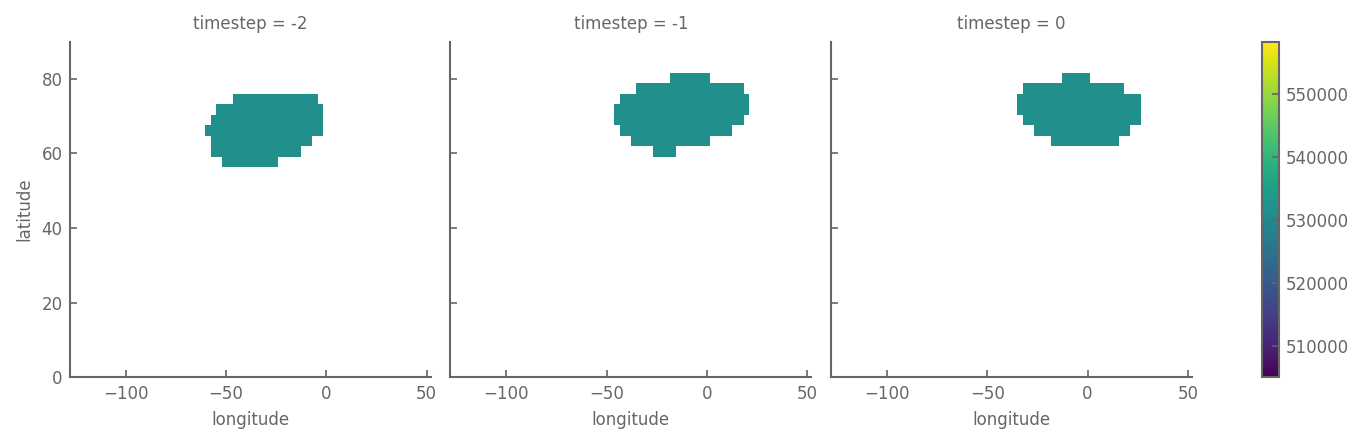

In [436]:
distance_from_cyclone = 1000 #km
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe()
cycs['day'] = cycs.date.dt.round('D')

cycs_extract= cycs.loc[cycs.track_id.isin(cyclones_time)]
cycs_extract = cycs_extract.loc[cycs_extract.date.round('D')<=pd.to_datetime(time)]

grid = xr.zeros_like(true_attrs.isel(timestep=0, var_name=0))#.expand_dims(time=cycs_extract.day.unique())

lon_center = cycs_extract.lon.to_xarray().rename(index='cyclone_index')
lat_center = cycs_extract.lat.to_xarray().rename(index='cyclone_index')
date = cycs_extract.day.to_xarray().rename(index='cyclone_index')
track_id = cycs_extract.track_id.to_xarray().rename(index='cyclone_index')

distances = haversine_np(lon_center,lat_center,grid+grid.longitude, grid+grid.latitude)
# distances = distances.where(distances<distance_from_cyclone)
distances = distances.where(distances == distances.groupby(date).min())
distances = distances.assign_coords(day=np.arange(-distances.day.size+1,1)).drop_vars('timestep').rename(day='timestep')

cyclones_tracks = (distances.where(distances<distance_from_cyclone)-distances+track_id).max('cyclone_index')


distances = distances.min('cyclone_index')
distances.plot(col='timestep')
cyclones_tracks.plot(col='timestep')

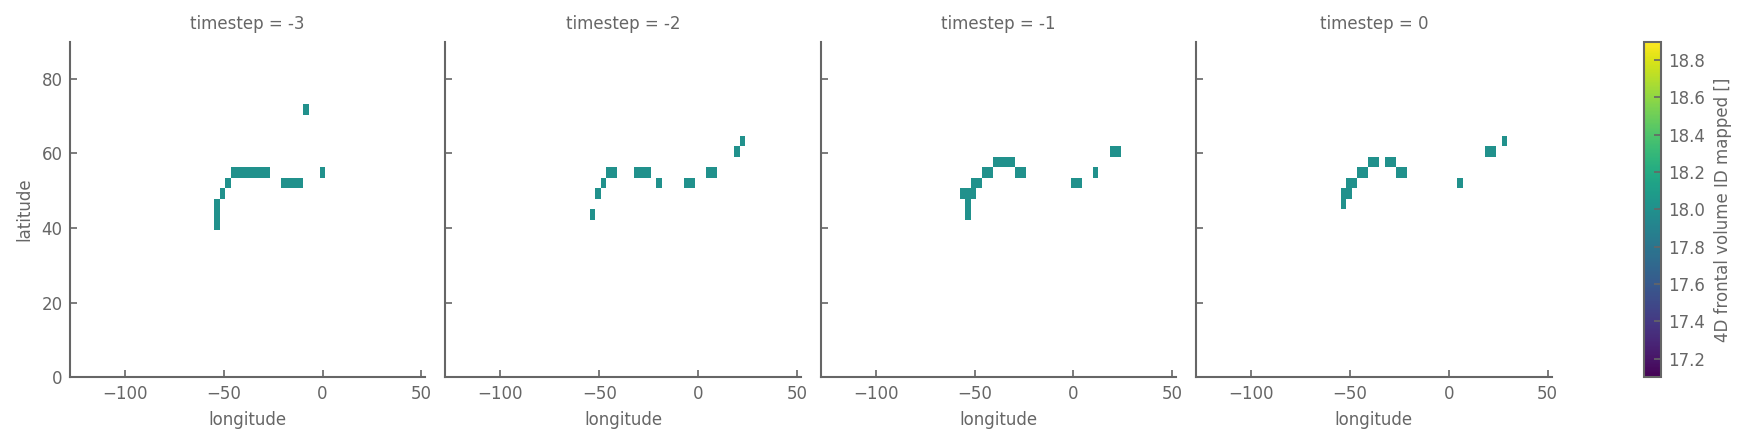

In [437]:
file1 = f'/Data/gfi/spengler/jlu044/era5_4D_frovo/frovo_4D_v1_1_mountain_NH/frovo_4D_data_{year}-{month}.nc'
if int(month)==1:
    year2 = str(int(year)-1)
    month2 = '12'
else:
    year2=year
    month2 = f"{int(month)-1:02d}"
file2 = f'/Data/gfi/spengler/jlu044/era5_4D_frovo/frovo_4D_v1_1_mountain_NH/frovo_4D_data_{year2}-{month2}.nc'
ds1 = xr.open_dataset(file1).frovo_id_mapped
ds2 = xr.open_dataset(file2).frovo_id_mapped
frovo = xr.concat([ds2, ds1], dim='time')
# frovo = xr.open_mfdataset([file1, file2]).load()
frovo = frovo.rename(dict(lat = 'latitude',lon = 'longitude')).sel(pressure=850).interp_like(grid, method = 'nearest')
frovo = frovo.where(frovo.isin(fronts_time)).sel(time=slice(None,time))
frovo = frovo.where(frovo.max(['longitude','latitude']).notnull(), drop=True)
# frovo = frovo.resample(time='D').count()
frovo = frovo.where(frovo>0).isel(time=slice(-4,None))
frovo = frovo.rename(time='timestep').assign_coords(timestep=np.arange(-3,1))
frovo.plot(col='timestep')

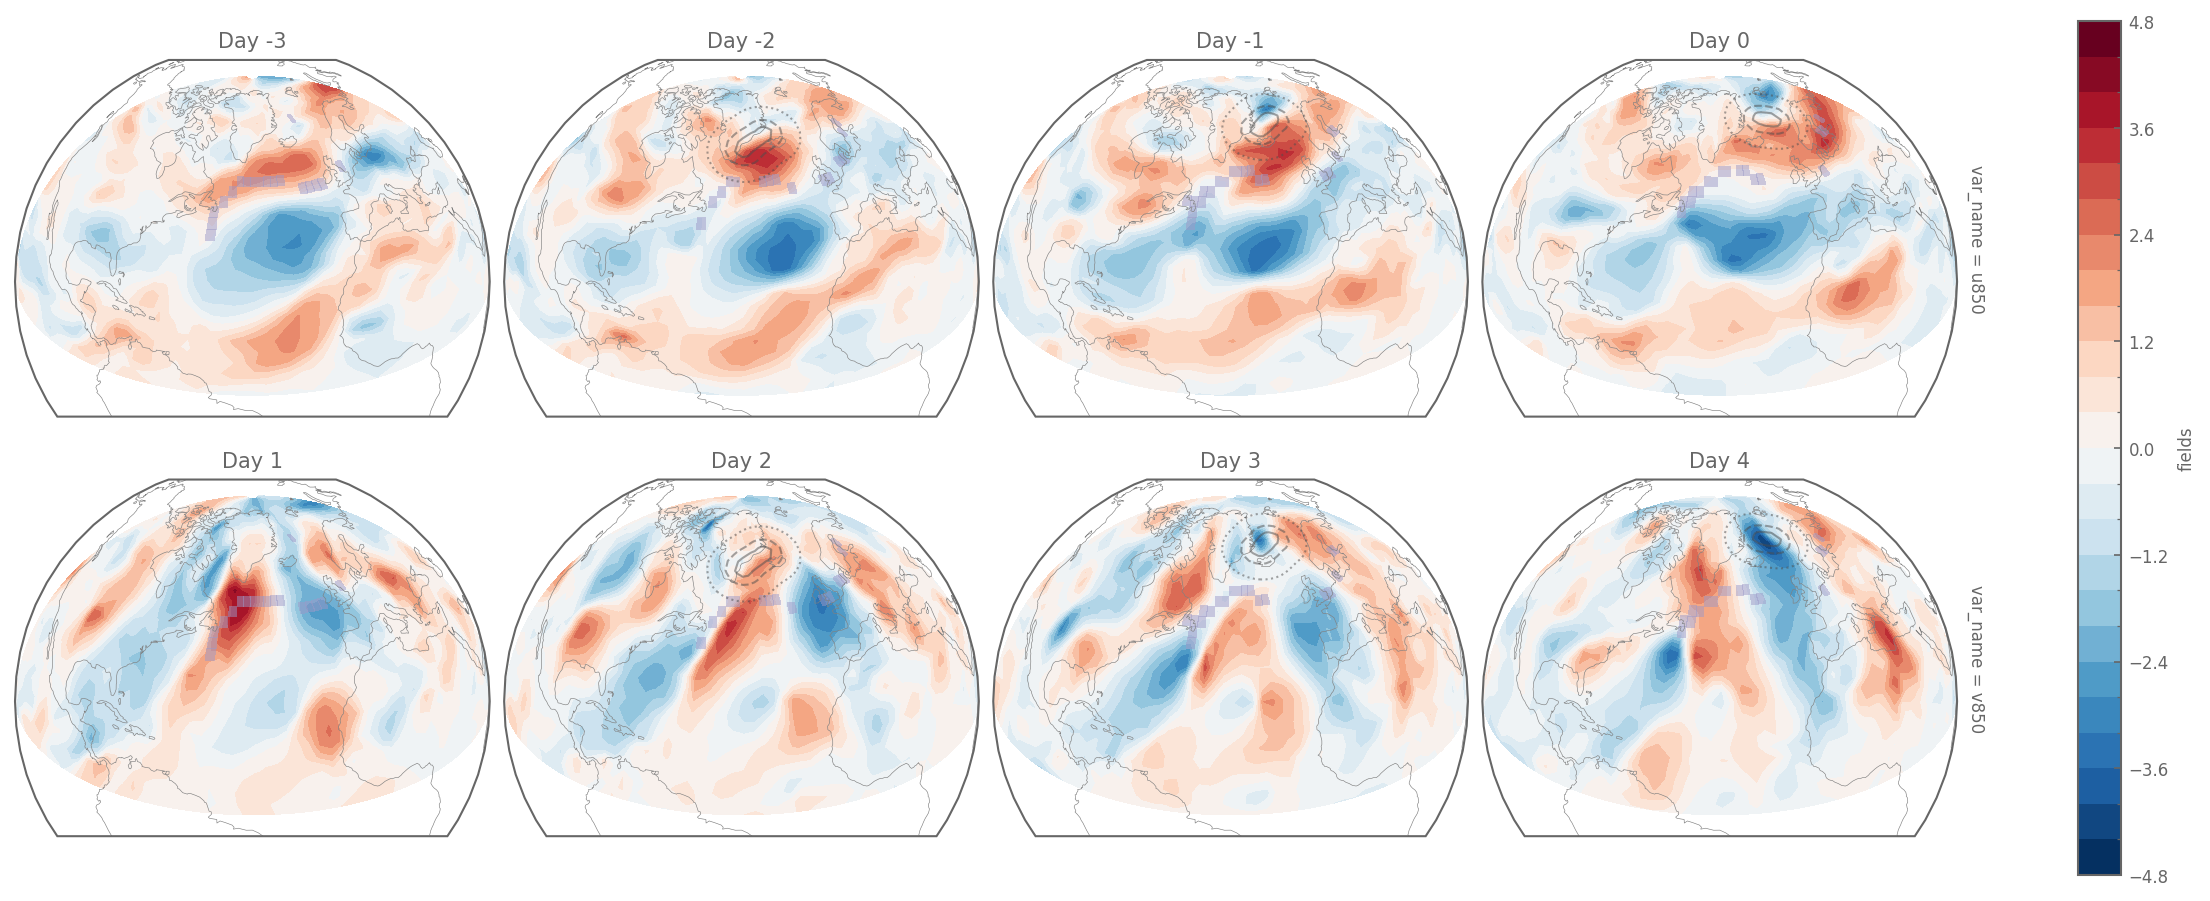

In [449]:
ds_diag = xr.Dataset(dict(attributions = true_attrs, cycl_track = cyclones_tracks, distance_from_cyclone= distances, 
                          fields=fields, fronts=frovo)).sel(timestep=range(-3,1))


plot = ds_diag.fields.plot.contourf(col='timestep', row='var_name', subplot_kws=dict(projection=ccrs.Orthographic(-40, 30)), transform=ccrs.PlateCarree(), size=3, aspect=1.3,levels=30)

cyclone_contour_kwargs =dict( levels=[250,500,1000], alpha=.5, colors=['.3','.3','.3'], linestyles=['-','--',':'])
fronts_kwargs =dict(  alpha=.5,add_colorbar=False, cmap='Purples')

for k, ax in enumerate(plot.axs.flatten()):
    ax.coastlines(linewidth=.3, color='.5')
    if k<4:
        ds_diag.distance_from_cyclone.sel(timestep=-3+k).plot.contour(ax=ax, transform=ccrs.PlateCarree(), **cyclone_contour_kwargs)
        ds_diag.fronts.sel(timestep=-3+k).plot(ax=ax, transform=ccrs.PlateCarree(), **fronts_kwargs)
        ax.set_title(f'Day {-3+k}')
    if k>=4:
        ds_diag.distance_from_cyclone.sel(timestep=-3+k-4).plot.contour(ax=ax, transform=ccrs.PlateCarree(), **cyclone_contour_kwargs)
        ds_diag.fronts.sel(timestep=-3+k-4).plot(ax=ax, transform=ccrs.PlateCarree(), **fronts_kwargs)

        ax.set_title(f'Day {-3+k}')

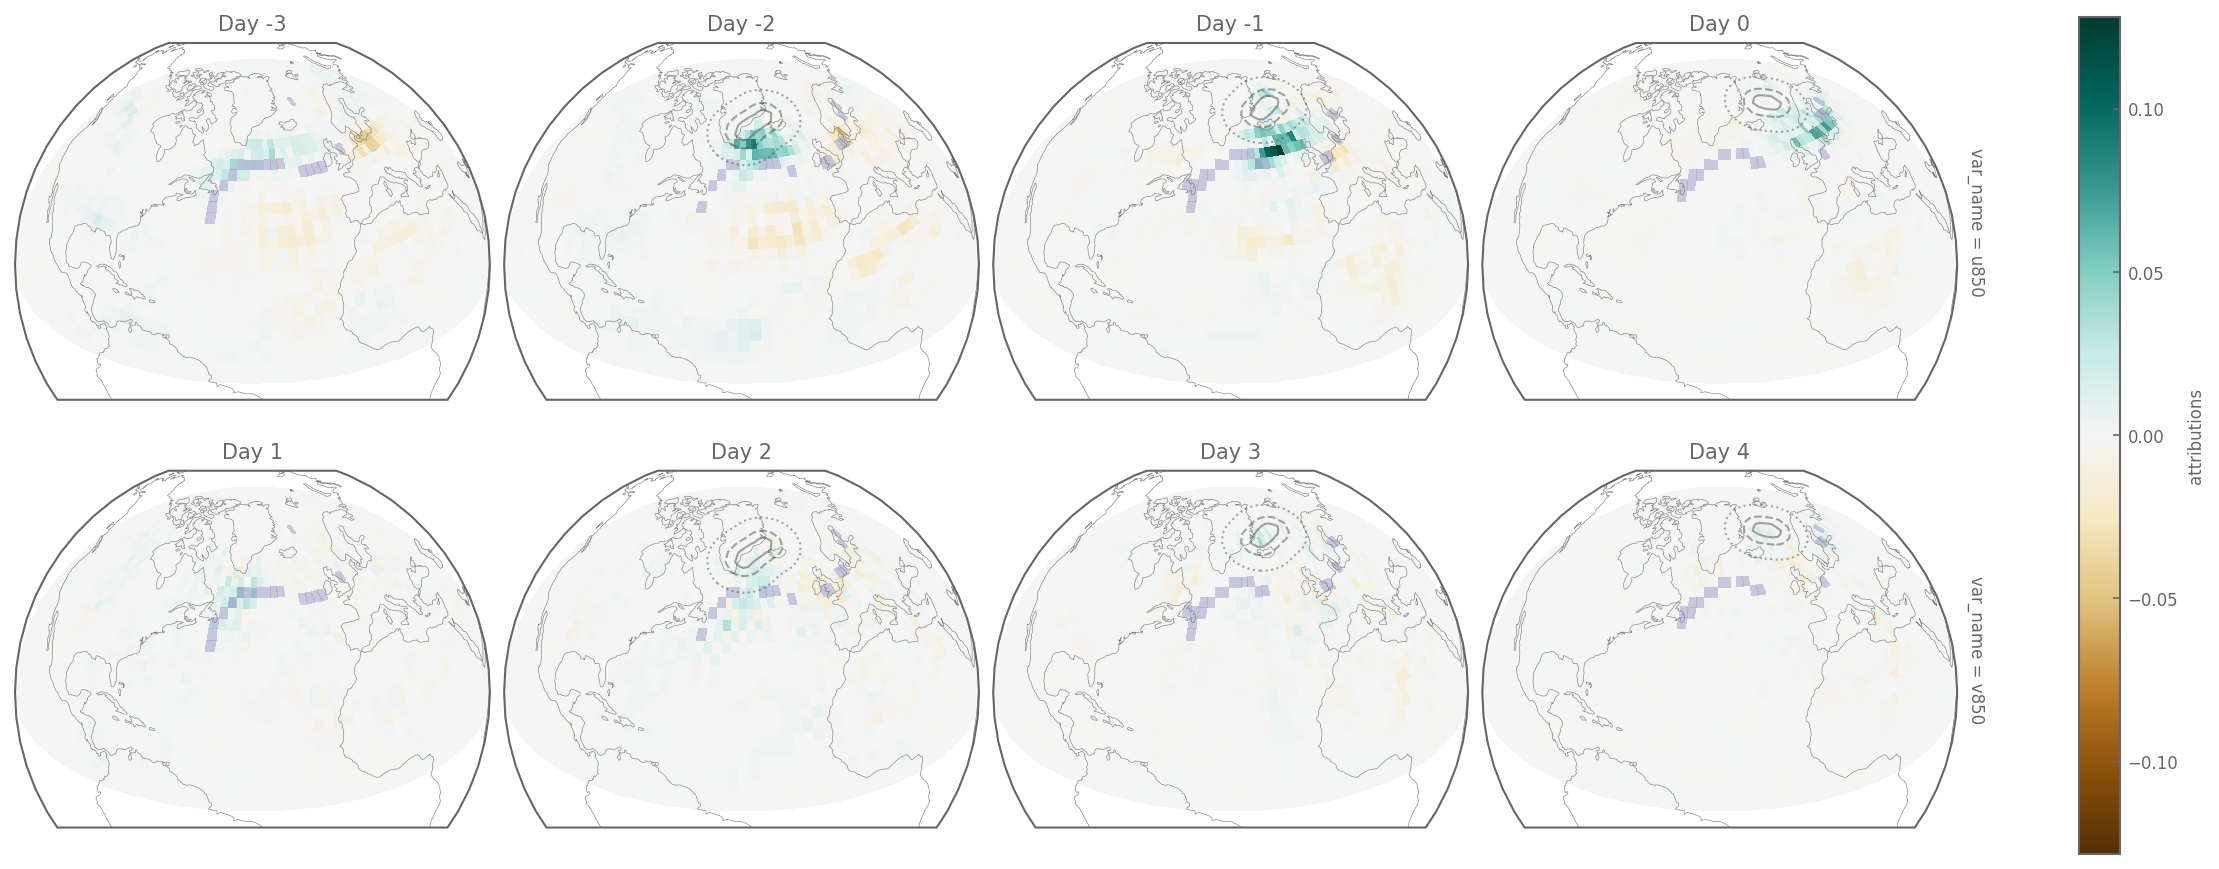

In [450]:
ds_diag = xr.Dataset(dict(attributions = true_attrs, cycl_track = cyclones_tracks, distance_from_cyclone= distances, 
                          fields=fields, fronts=frovo)).sel(timestep=range(-3,1))


plot = ds_diag.attributions.plot(col='timestep', row='var_name', subplot_kws=dict(projection=ccrs.Orthographic(-40, 30)), transform=ccrs.PlateCarree(), size=3, aspect=1.3,cmap='BrBG')

cyclone_contour_kwargs =dict( levels=[250,500,1000], alpha=.5, colors=['.3','.3','.3'], linestyles=['-','--',':'])
fronts_kwargs =dict(  alpha=.5,add_colorbar=False, cmap='Purples')

for k, ax in enumerate(plot.axs.flatten()):
    ax.coastlines(linewidth=.3, color='.5')
    if k<4:
        ds_diag.distance_from_cyclone.sel(timestep=-3+k).plot.contour(ax=ax, transform=ccrs.PlateCarree(), **cyclone_contour_kwargs)
        ds_diag.fronts.sel(timestep=-3+k).plot(ax=ax, transform=ccrs.PlateCarree(), **fronts_kwargs)
        ax.set_title(f'Day {-3+k}')
    if k>=4:
        ds_diag.distance_from_cyclone.sel(timestep=-3+k-4).plot.contour(ax=ax, transform=ccrs.PlateCarree(), **cyclone_contour_kwargs)
        ds_diag.fronts.sel(timestep=-3+k-4).plot(ax=ax, transform=ccrs.PlateCarree(), **fronts_kwargs)

        ax.set_title(f'Day {-3+k}')

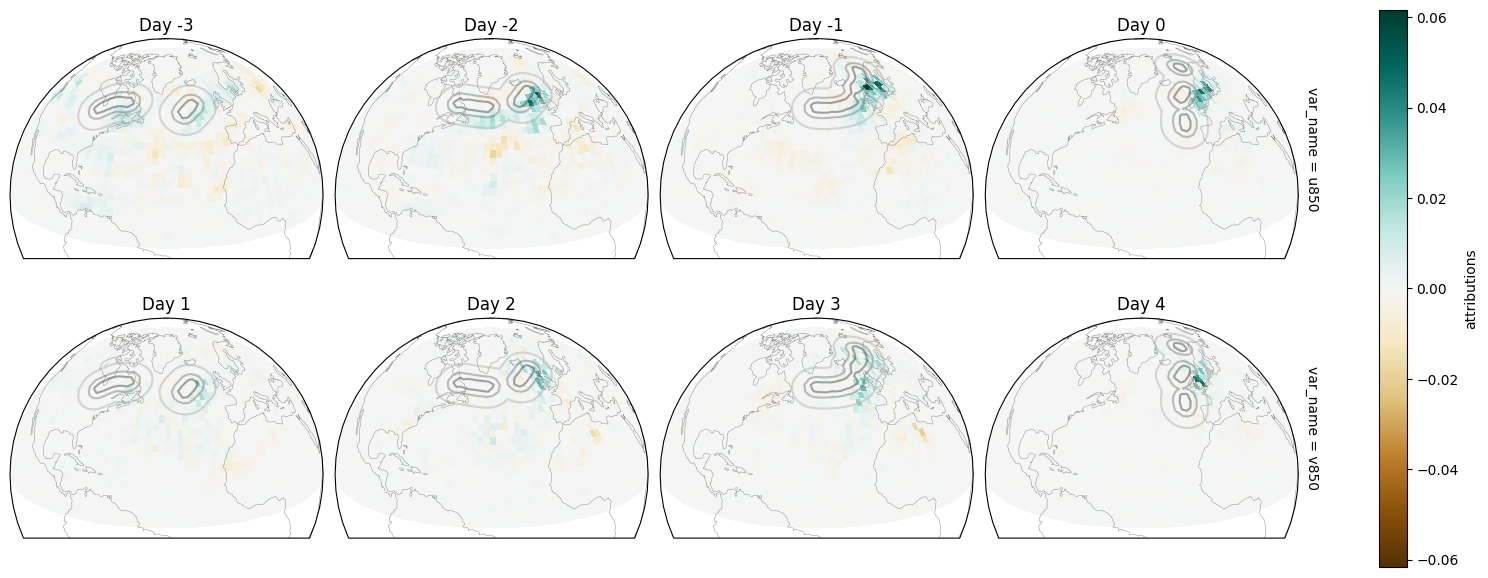

In [249]:
plot = ds_diag.attributions.plot(col='timestep', row='var_name', subplot_kws=dict(projection=ccrs.Orthographic(-40, 20)), transform=ccrs.PlateCarree(), size=3, aspect=1.3, cmap='BrBG')

cyclone_contour_kwargs =dict( levels=[250,500,1000], alpha=.5, colors=['.3','.5','.7'])
for k, ax in enumerate(plot.axs.flatten()):
    ax.coastlines(linewidth=.3, color='.5')
    if k<4:
        ds_diag.distance_from_cyclone.sel(timestep=-3+k).plot.contour(ax=ax, transform=ccrs.PlateCarree(), **cyclone_contour_kwargs)
        ax.set_title(f'Day {-3+k}')
    if k>=4:
        ds_diag.distance_from_cyclone.sel(timestep=-3+k-4).plot.contour(ax=ax, transform=ccrs.PlateCarree(), **cyclone_contour_kwargs)
        ax.set_title(f'Day {-3+k}')

In [235]:
df_.groupby(['timestep','cycl_track']).attributions.sum().unstack()

cycl_track,0.0,427768.0,427863.0,428012.0
timestep,,,,
-3,-0.014326,0.263751,0.243114,NaN
-2,-0.409600,0.139648,0.889282,NaN
-1,-0.648440,0.385043,1.054838,NaN
0,0.114201,0.606208,0.116654,-0.011407


In [267]:
df_.distance_from_cyclone.quantile(np.arange(0,1.1,.1))

0.0       15.614872
0.1     1022.168008
0.2     1619.038863
0.3     2136.120818
0.4     2599.464188
0.5     3103.187190
0.6     3607.528100
0.7     4309.942469
0.8     5166.258970
0.9     6182.860497
1.0    11246.234361
Name: distance_from_cyclone, dtype: float64

In [366]:
new_index

NameError: name 'new_index' is not defined

In [387]:
num_points = df_.groupby([df_.timestep,np.sign(df_.attributions),pd.cut(df_.distance_from_cyclone, np.arange(0,10000,250))]).attributions.count()
sum_attrs = df_.groupby([df_.timestep,np.sign(df_.attributions),pd.cut(df_.distance_from_cyclone, np.arange(0,10000,250))]).attributions.sum()
mean_attrs = df_.groupby([df_.timestep,np.sign(df_.attributions),pd.cut(df_.distance_from_cyclone, np.arange(0,10000,250))]).attributions.mean()

df__ = pd.DataFrame(dict(num_points=num_points, sum_attrs=sum_attrs, mean_attrs=mean_attrs))
# new_index = df__.index.set_levels(
#    [k.mid for k in df__.index.get_level_values(1)], level=1  # modify level 1
# )
# # Assign new index back
# df__.index = new_index
# # df__.index =  np.arange(125,10000-250,250)

/tmp/ipykernel_183475/672641524.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  num_points = df_.groupby([df_.timestep,np.sign(df_.attributions),pd.cut(df_.distance_from_cyclone, np.arange(0,10000,250))]).attributions.count()
/tmp/ipykernel_183475/672641524.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_attrs = df_.groupby([df_.timestep,np.sign(df_.attributions),pd.cut(df_.distance_from_cyclone, np.arange(0,10000,250))]).attributions.sum()
/tmp/ipykernel_183475/672641524.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pas

MultiIndex([(-3,     (0, 250]),
            (-3,   (250, 500]),
            (-3,   (500, 750]),
            (-3,  (750, 1000]),
            (-3, (1000, 1250]),
            (-3, (1250, 1500]),
            (-3, (1500, 1750]),
            (-3, (1750, 2000]),
            (-3, (2000, 2250]),
            (-3, (2250, 2500]),
            ...
            ( 0, (7250, 7500]),
            ( 0, (7500, 7750]),
            ( 0, (7750, 8000]),
            ( 0, (8000, 8250]),
            ( 0, (8250, 8500]),
            ( 0, (8500, 8750]),
            ( 0, (8750, 9000]),
            ( 0, (9000, 9250]),
            ( 0, (9250, 9500]),
            ( 0, (9500, 9750])],
           names=['timestep', 'distance_from_cyclone'], length=156)

In [390]:
df__.loc[k-3,1]+

,num_points,sum_attrs,mean_attrs
distance_from_cyclone,,,
"(0, 250]",24,0.043766,0.001824
"(250, 500]",51,0.146374,0.002870
"(500, 750]",81,0.390712,0.004824
"(750, 1000]",88,0.332998,0.003784
"(1000, 1250]",92,0.272438,0.002961
"(1250, 1500]",89,0.074440,0.000836
"(1500, 1750]",103,0.048516,0.000471
"(1750, 2000]",102,0.017941,0.000176
"(2000, 2250]",84,0.011492,0.000137


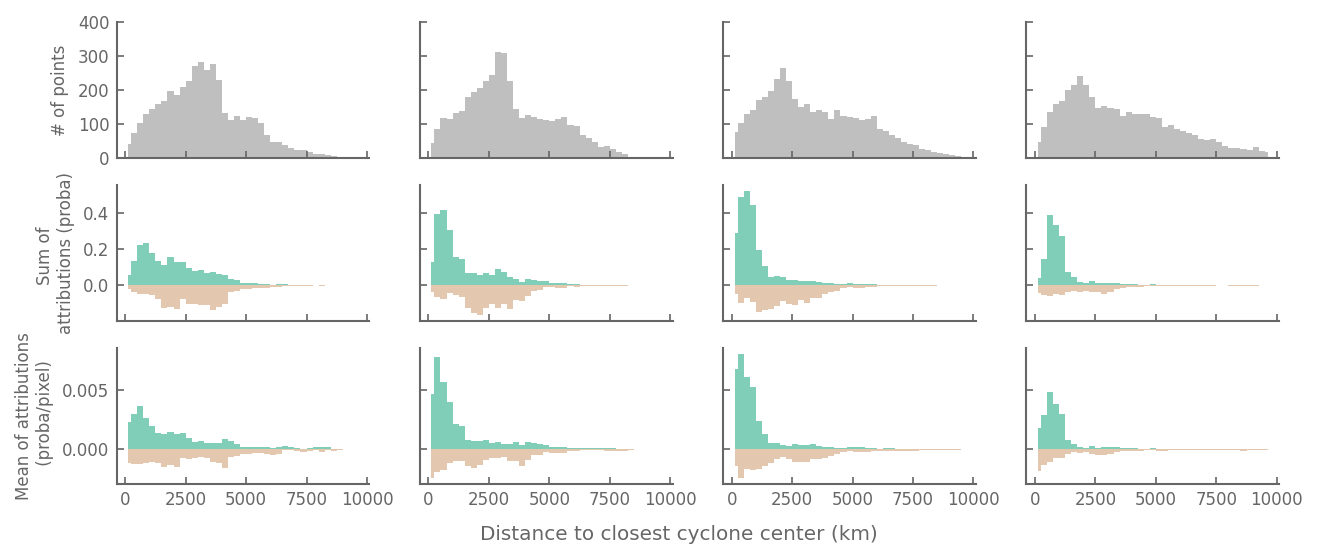

In [396]:
fig, axs = plt.subplots(3,4, figsize=(10,4), sharex=True,sharey='row')
for k in range(4):
    axs[0,k].fill_between([k.mid for k in df__.loc[k-3,1].index], df__.loc[k-3,1].num_points+df__.loc[k-3,-1].num_points, step="mid", alpha=0.5, color='.5', linewidth=0) 
    axs[1,k].fill_between([k.mid for k in df__.loc[k-3,1].index], df__.loc[k-3,1].sum_attrs.fillna(0), step="mid", alpha=0.5, color='C2', linewidth=0) 
    axs[1,k].fill_between([k.mid for k in df__.loc[k-3,-1].index], df__.loc[k-3,-1].sum_attrs.fillna(0), step="mid", alpha=0.5, color='C5', linewidth=0) 
    
    axs[2,k].fill_between([k.mid for k in df__.loc[k-3,1].index], df__.loc[k-3,1].mean_attrs.fillna(0), step="mid", alpha=0.5, color='C2', linewidth=0) 
    axs[2,k].fill_between([k.mid for k in df__.loc[k-3,-1].index], df__.loc[k-3,-1].mean_attrs.fillna(0), step="mid", alpha=0.5, color='C5', linewidth=0) 
    
    
    axs[0,k].set_ylim(0,400)
    if k==0:
        axs[0,k].set_ylabel('# of points')
        axs[1,k].set_ylabel('Sum of \nattributions (proba)' )
        axs[2,k].set_ylabel('Mean of attributions\n (proba/pixel)')
        
    fig.supxlabel('Distance to closest cyclone center (km)')

In [ ]:
df__

In [318]:
df__.where(df__.sum_attrs>0).sum_attrs

125     0.383884
375     0.909334
625     1.303496
875     1.090417
1125    0.491071
1375    0.158514
1625         NaN
1875         NaN
2125         NaN
2375         NaN
2625         NaN
2875         NaN
3125         NaN
3375         NaN
3625         NaN
3875         NaN
4125         NaN
4375         NaN
4625         NaN
4875    0.012251
5125         NaN
5375         NaN
5625         NaN
5875         NaN
6125         NaN
6375    0.001551
6625    0.007543
6875    0.005370
7125    0.002682
7375         NaN
7625    0.000396
7875         NaN
8125    0.000352
8375    0.000825
8625         NaN
8875    0.000162
9125         NaN
9375    0.000086
9625         NaN
Name: sum_attrs, dtype: float32

/tmp/ipykernel_183475/1956181910.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_.groupby(pd.cut(df_.distance_from_cyclone, np.arange(0,10000,250))).attributions.sum().plot.barh()


<Axes: ylabel='distance_from_cyclone'>

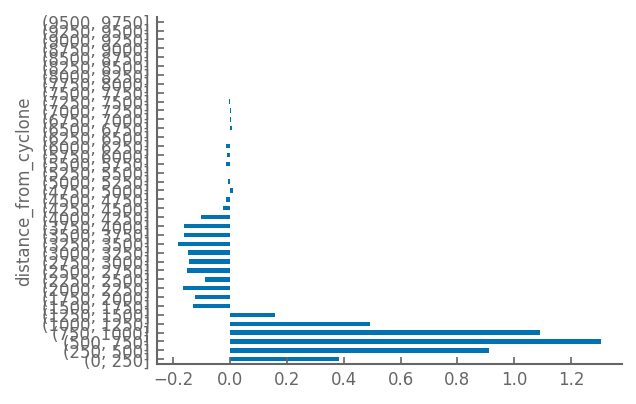

In [277]:
df_.groupby(pd.cut(df_.distance_from_cyclone, np.arange(0,10000,250))).attributions.sum()

# df_.groupby(pd.cut(df_.distance_from_cyclone, df_.distance_from_cyclone.quantile(np.arange(0,1.1,.1)))).attributions.sum().plot.barh()

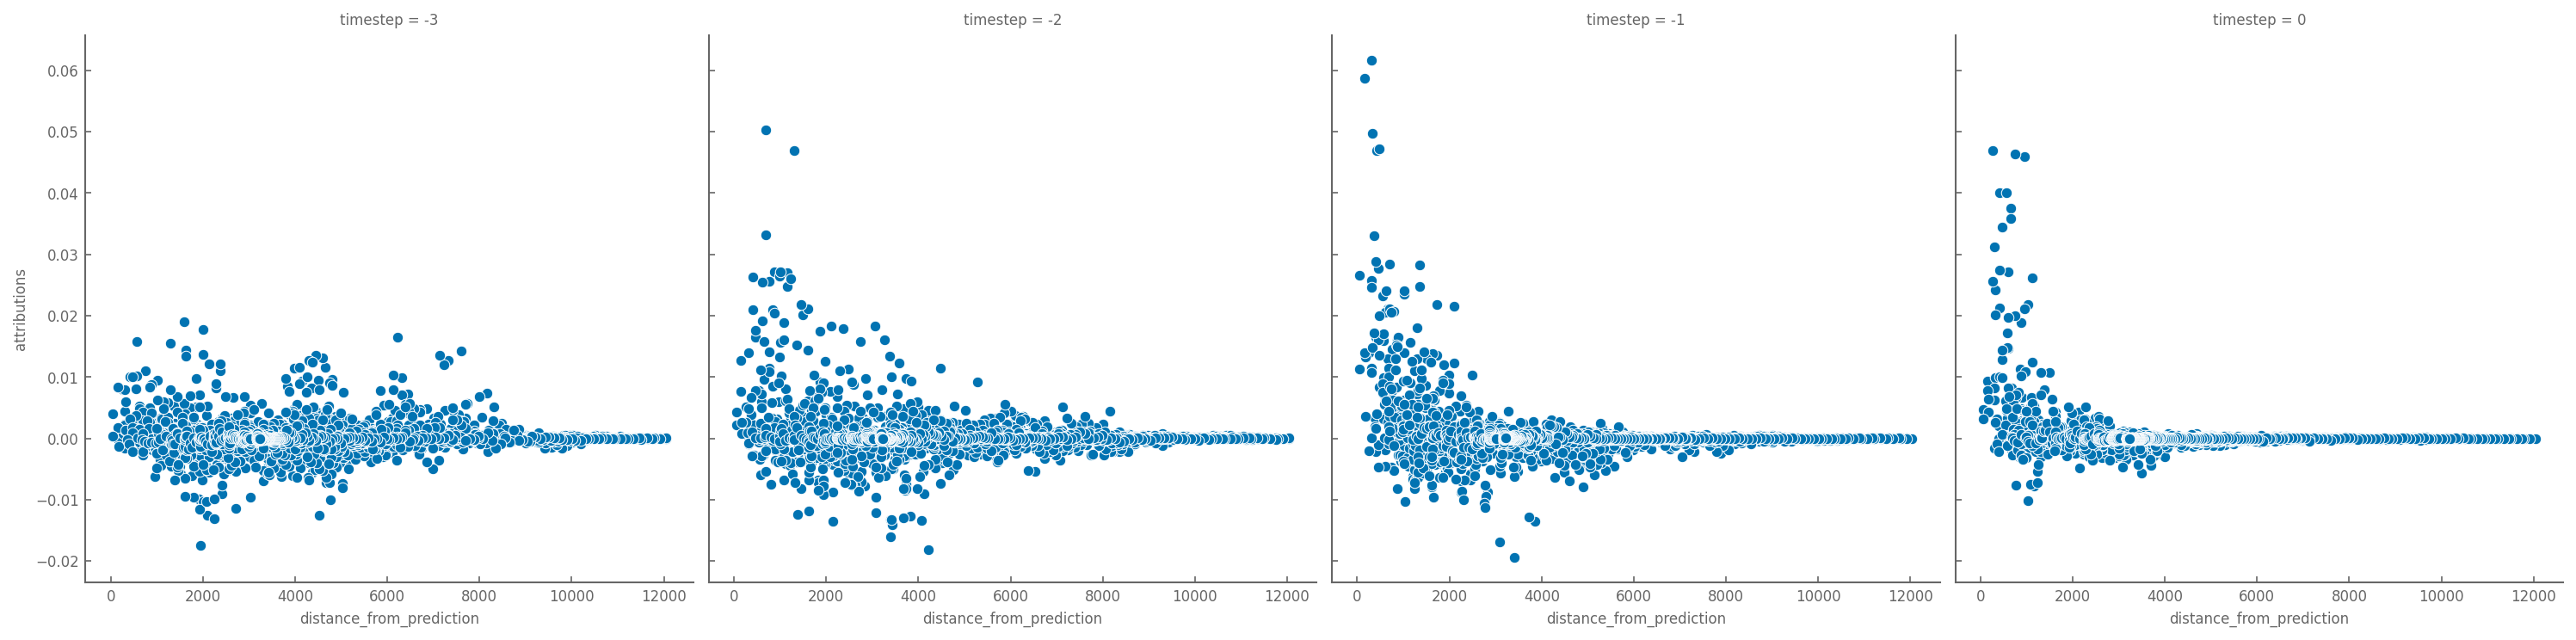

In [402]:
df_ = ds_diag.to_dataframe().reset_index()
df_['distance_from_prediction'] = haversine_np(df_.longitude, df_.latitude, 5.5, 60)
df_['cycl_track'] = df_.cycl_track.fillna(0)
sns.relplot(df_,x='distance_from_prediction', y='attributions', col='timestep')

In [111]:
fronts_time

[129, 27611]

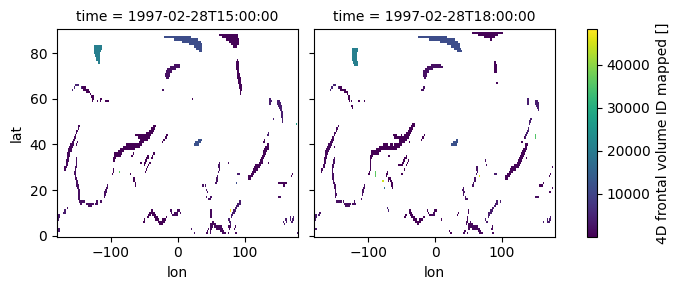

<Figure size 640x480 with 0 Axes>

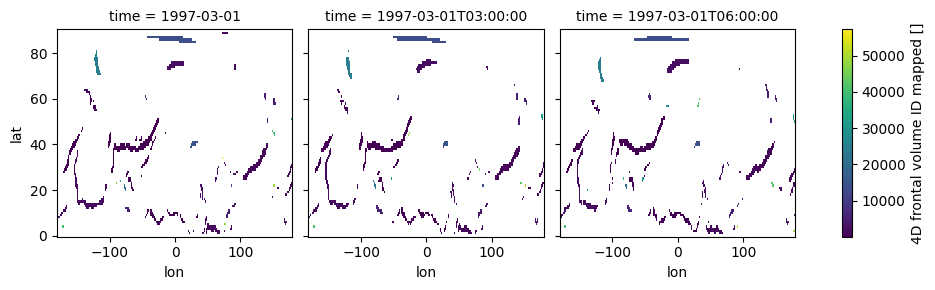

In [98]:
ds2.frovo_id_mapped.where(ds2.frovo_id_mapped>0).isel(time=range(-3,-1)).sel(pressure=850).plot(col='time')
plt.figure()
ds1.frovo_id_mapped.where(ds1.frovo_id_mapped>0).isel(time=range(0,3)).sel(pressure=850).plot(col='time')


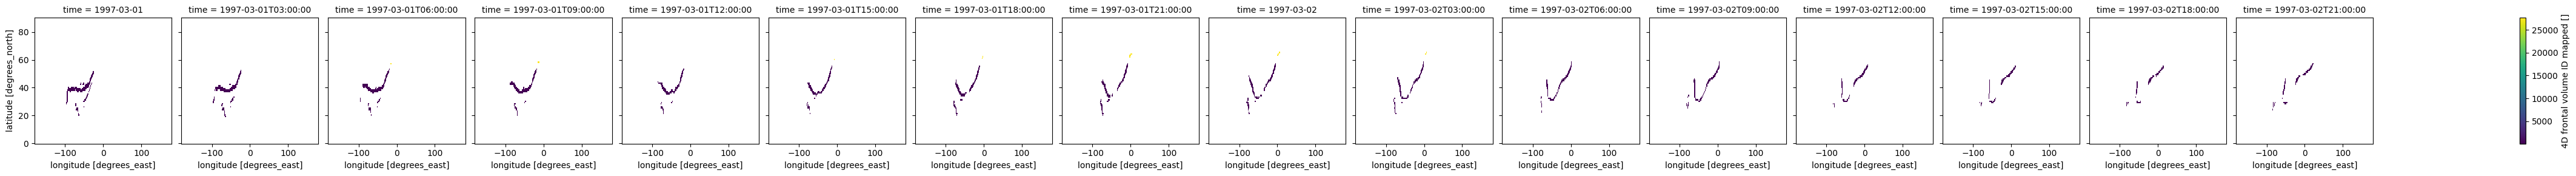

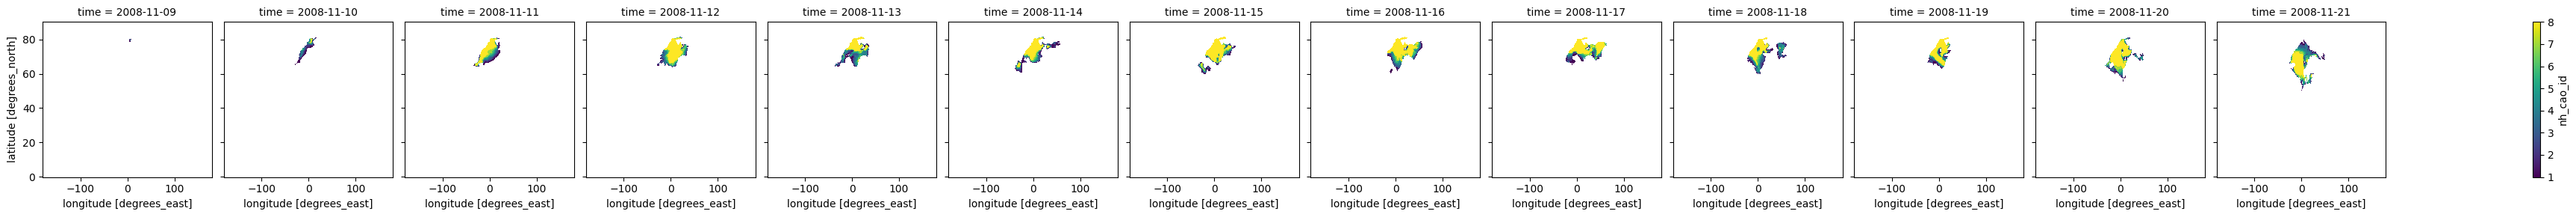

In [10]:
file1 = f'/Data/gfi/share/era5/detected_features/cold_air_outbreak_events/ea.ans.{year}{month}.sfc.nh_cao_id.nc'
file2 = f'/Data/gfi/share/era5/detected_features/cold_air_outbreak_events/ea.ans.{year2}{month2}.sfc.nh_cao_id.nc'

caos = xr.open_mfdataset([file1, file2]).nh_cao_id.interp_like(grid, method = 'nearest')
caos = caos.where(caos.isin(caos_time)).sel(time=slice(None,time))
caos = caos.where(caos.max(['longitude','latitude']).notnull(), drop=True)
caos = caos.resample(time='D').count()
caos = caos.where(caos>0)
caos.plot(col='time')

In [11]:
distance_from_mta = 200 #km

mta = xr.open_dataset(f'/Data/gfi/share/era5/detected_features/moisture_transport_axis/ea.ans.{year}{month}.sfc.mta.nc').to_dataframe()
# mta = mta.loc[(mta.date<=pd.to_datetime(time)) & (mta.date >= pd.to_datetime(time) -pd.Timedelta(8,'D'))]
grid = xr.zeros_like(ds.F.isel(time=0))#.expand_dims(time=mta.day.unique())

# lon_center = mta.longitude.to_xarray().rename(index='cyclone_index')
# lat_center = mta.latitude.to_xarray().rename(index='cyclone_index')
# date = mta.date.to_xarray().rename(index='cyclone_index')

# distances = haversine_np(lon_center,lat_center,grid+grid.longitude, grid+grid.latitude)
# distances = distances.where(distances<distance_from_cyclone)
# distances = distances.where(distances == distances.groupby(date).min())

In [23]:
mta_time = features_time.where(features_time.apply(lambda series:series.str.startswith('A_'))).dropna(how='all').T.dropna(how='all').T
mta_time['line_id'] = mta_time[0].str.split('_', expand=True)[1]
mta_time.line_id

time
2008-11-21 00:00:00    10
2008-11-21 03:00:00    14
2008-11-21 06:00:00    11
2008-11-21 09:00:00    11
Name: line_id, dtype: object

In [42]:
mean_mta.loc['2008-11-21 09:00:00', 11]


latitude      55.488461
longitude    -13.503525
viwvt        449.392666
Name: (2008-11-21 09:00:00, 11), dtype: float64

In [40]:
mean_mta= mta.groupby(['date','line_id']).mean()
mta_select = mean_mta.loc['2008-11-21 09:00:00', 11]

dist = haversine_np(mean_mta.longitude, mean_mta.latitude, mta_select.longitude,mta_select.latitude).unstack().T
dist.idxmin()

date
2008-11-01 00:00:00    21
2008-11-01 03:00:00    19
2008-11-01 06:00:00    19
2008-11-01 09:00:00    19
2008-11-01 12:00:00    20
                       ..
2008-11-30 09:00:00    18
2008-11-30 12:00:00    12
2008-11-30 15:00:00    12
2008-11-30 18:00:00    12
2008-11-30 21:00:00    11
Length: 240, dtype: int64

In [29]:
center_mta = mta.groupby(['date','line_id']).mean()
center_mta.loc[center_mta.index.get_level_values(1)==pd.to_datetime('2008-11-21 09:00:00')]

,,latitude,longitude,viwvt
date,line_id,,,


In [25]:
center_mta.index.get_level_values(1)

DatetimeIndex(['2008-11-13 00:00:00', '2008-11-13 03:00:00',
               '2008-11-13 06:00:00', '2008-11-13 09:00:00',
               '2008-11-13 12:00:00', '2008-11-13 15:00:00',
               '2008-11-13 18:00:00', '2008-11-13 21:00:00',
               '2008-11-14 00:00:00', '2008-11-14 03:00:00',
               ...
               '2008-11-16 09:00:00', '2008-11-18 06:00:00',
               '2008-11-18 09:00:00', '2008-11-19 06:00:00',
               '2008-11-18 06:00:00', '2008-11-18 09:00:00',
               '2008-11-19 06:00:00', '2008-11-18 09:00:00',
               '2008-11-19 06:00:00', '2008-11-18 09:00:00'],
              dtype='datetime64[ns]', name='date', length=1719, freq=None)

<Axes: xlabel='longitude', ylabel='latitude'>

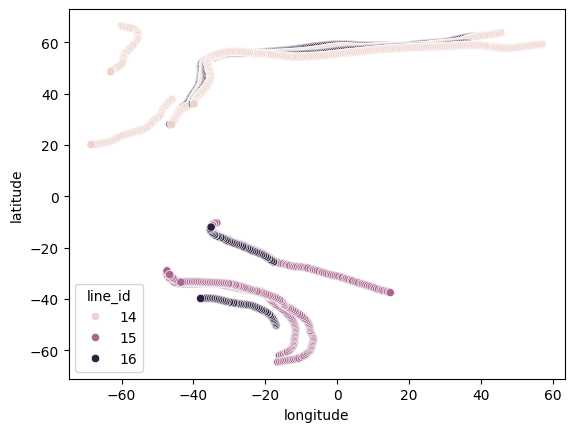

In [236]:
sns.scatterplot(mta.loc[(mta.date.dt.round('D')==pd.to_datetime(time)) & (mta.line_id.isin(moistureaxis_time))], x='longitude',y='latitude', hue='line_id')

In [281]:
centroid1 = mta.groupby(['date','line_id']).mean()[['longitude','latitude']].to_xarray()
centroid2 = mta.groupby(['date','line_id']).mean()[['longitude','latitude']].to_xarray().rename(line_id='line_id2',date='date2').shift(date2=1)

In [270]:
distances.date
# pd.to_datetime(time)

<xarray.DataArray 'date' (date: 63)> Size: 504B
array(['2005-11-07T03:00:00.000000000', '2005-11-07T06:00:00.000000000',
       '2005-11-07T09:00:00.000000000', '2005-11-07T12:00:00.000000000',
       '2005-11-07T15:00:00.000000000', '2005-11-07T18:00:00.000000000',
       '2005-11-07T21:00:00.000000000', '2005-11-08T00:00:00.000000000',
       '2005-11-08T03:00:00.000000000', '2005-11-08T06:00:00.000000000',
       '2005-11-08T09:00:00.000000000', '2005-11-08T12:00:00.000000000',
       '2005-11-08T15:00:00.000000000', '2005-11-08T18:00:00.000000000',
       '2005-11-08T21:00:00.000000000', '2005-11-09T00:00:00.000000000',
       '2005-11-09T03:00:00.000000000', '2005-11-09T06:00:00.000000000',
       '2005-11-09T09:00:00.000000000', '2005-11-09T12:00:00.000000000',
       '2005-11-09T15:00:00.000000000', '2005-11-09T18:00:00.000000000',
       '2005-11-09T21:00:00.000000000', '2005-11-10T00:00:00.000000000',
       '2005-11-10T03:00:00.000000000', '2005-11-10T06:00:00.000000000',
       '2005-11-10T09:00:00.000000000', '2005-11-10T12:00:00.000000000',
       '2005-11-10T15:00:00.000000000', '2005-11-10T18:00:00.000000000',
       '2005-11-10T21:00:00.000000000', '2005-11-11T00:00:00.000000000',
       '2005-11-11T03:00:00.000000000', '2005-11-11T06:00:00.000000000',
       '2005-11-11T09:00:00.000000000', '2005-11-11T12:00:00.000000000',
       '2005-11-11T15:00:00.000000000', '2005-11-11T18:00:00.000000000',
       '2005-11-11T21:00:00.000000000', '2005-11-12T00:00:00.000000000',
       '2005-11-12T03:00:00.000000000', '2005-11-12T06:00:00.000000000',
       '2005-11-12T09:00:00.000000000', '2005-11-12T12:00:00.000000000',
       '2005-11-12T15:00:00.000000000', '2005-11-12T18:00:00.000000000',
       '2005-11-12T21:00:00.000000000', '2005-11-13T00:00:00.000000000',
       '2005-11-13T03:00:00.000000000', '2005-11-13T06:00:00.000000000',
       '2005-11-13T09:00:00.000000000', '2005-11-13T12:00:00.000000000',
       '2005-11-13T15:00:00.000000000', '2005-11-13T18:00:00.000000000',
       '2005-11-13T21:00:00.000000000', '2005-11-14T00:00:00.000000000',
       '2005-11-14T03:00:00.000000000', '2005-11-14T06:00:00.000000000',
       '2005-11-14T09:00:00.000000000', '2005-11-14T12:00:00.000000000',
       '2005-11-14T15:00:00.000000000', '2005-11-14T18:00:00.000000000',
       '2005-11-14T21:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * date     (date) datetime64[ns] 504B 2005-11-07T03:00:00 ... 2005-11-14T21...

In [285]:
distances = haversine_np(centroid1.longitude,centroid1.latitude, centroid2.longitude, centroid2.latitude).fillna(100000)
distances.argmin('line_id2').sel(line_id=14)

<xarray.DataArray (date2: 65, date: 65)> Size: 34kB
array([[ 0,  0,  0, ...,  0,  0,  0],
       [13, 10, 13, ..., 10, 15,  1],
       [16, 13, 16, ..., 13, 18, 16],
       ...,
       [16,  9, 16, ..., 13, 13,  8],
       [ 0, 13,  0, ..., 13, 15,  9],
       [12,  0, 12, ...,  0, 13, 12]])
Coordinates:
  * date2    (date2) datetime64[ns] 520B 2005-11-07 ... 2005-11-15
  * date     (date) datetime64[ns] 520B 2005-11-07 ... 2005-11-15
    line_id  int64 8B 14

In [243]:
mta.loc[(mta.date.dt.round('D')==pd.to_datetime(time))].reset_index().pivot(index='index', columns=['line_id'], values=['longitude'])

longitude                                      ...                  \
line_id          1   2   3   4   5   6   7   8   9   10  ...  22  23  24  25   
index                                                    ...                   
215140  -168.000000 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
215141  -168.640535 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
215142  -168.794540 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
215143  -168.719767 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
215144  -168.550977 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
...             ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...  ..  ..  ..  ..   
223376          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
223377          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
223378          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
223379          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
223380          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   

                                        
line_id  26  27  28         29  30  31  
index                                   
215140  NaN NaN NaN        NaN NaN NaN  
215141  NaN NaN NaN        NaN NaN NaN  
215142  NaN NaN NaN        NaN NaN NaN  
215143  NaN NaN NaN        NaN NaN NaN  
215144  NaN NaN NaN        NaN NaN NaN  
...      ..  ..  ..        ...  ..  ..  
223376  NaN NaN NaN  157.50000 NaN NaN  
223377  NaN NaN NaN  156.96625 NaN NaN  
223378  NaN NaN NaN  156.50000 NaN NaN  
223379  NaN NaN NaN  156.00000 NaN NaN  
223380  NaN NaN NaN  155.50000 NaN NaN  

[8241 rows x 31 columns]

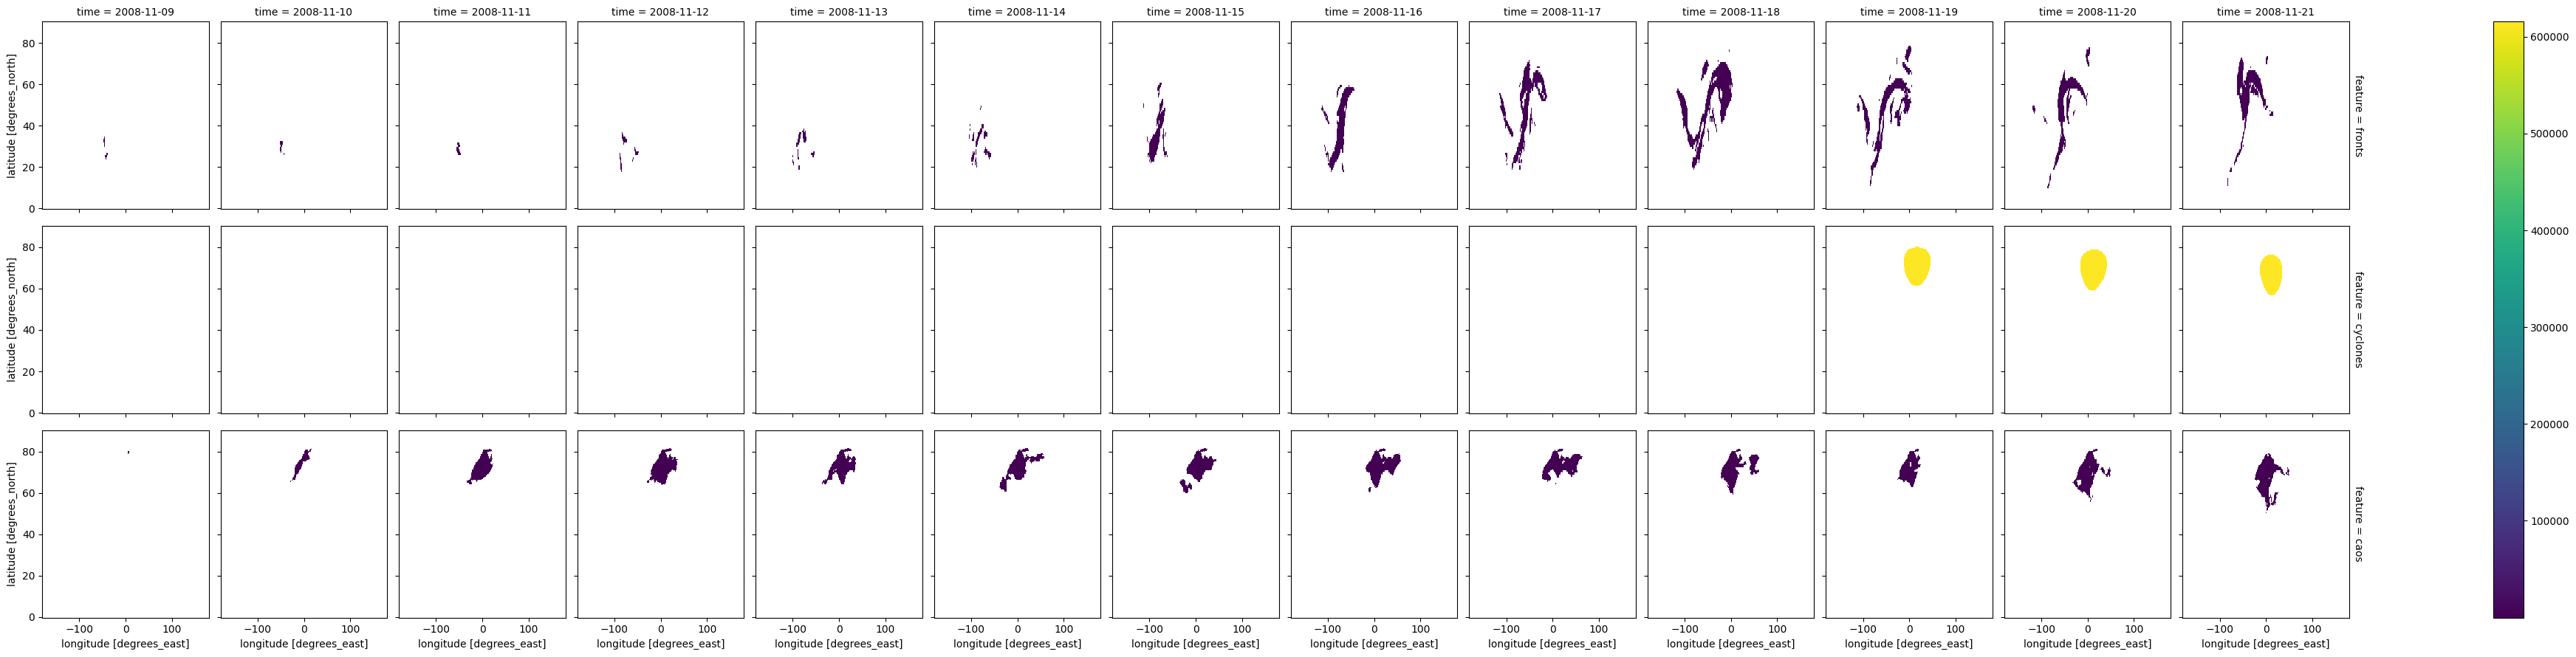

In [295]:
ds_features_one_day = xr.Dataset(dict(fronts=frovo, cyclones=cyclones_tracks, caos=caos)).to_array('feature')

ds_features_one_day.plot(col='time', row='feature')

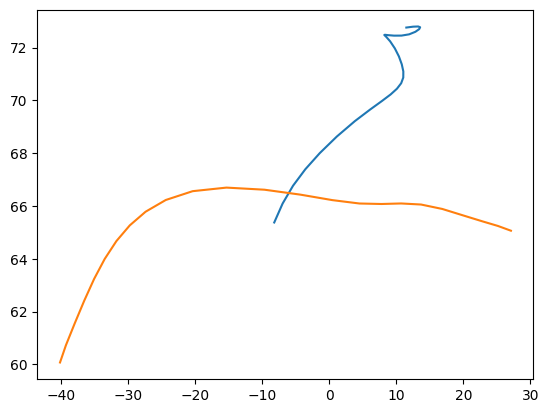

In [64]:
plt.plot( cycs.loc[cycs.track_id==cyclones_time[0]].lon, cycs.loc[cycs.track_id==cyclones_time[0]].lat)
plt.plot( cycs.loc[cycs.track_id==cyclones_time[1]].lon, cycs.loc[cycs.track_id==cyclones_time[1]].lat)

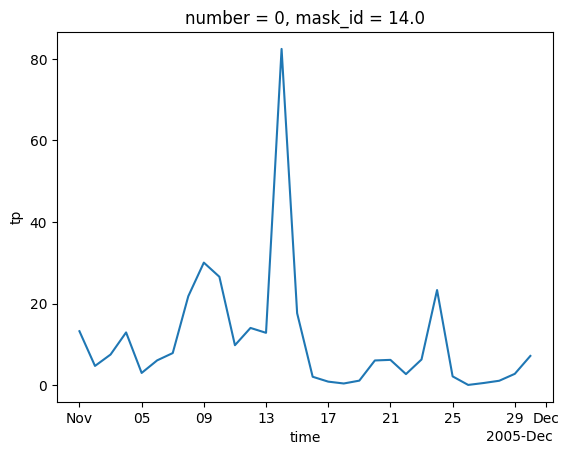

In [43]:
ds_rain.sel(time='2005-11').plot()

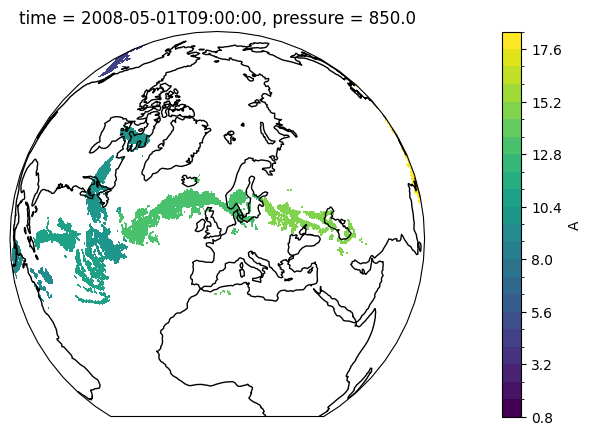

In [6]:
plot = ds.A.sel(time='2008-05-01 09:00:00').plot(subplot_kws=dict(projection = ccrs.Orthographic(0,50)), transform=ccrs.PlateCarree(), aspect=4, size=5, levels=25)
plot.axes.coastlines()

In [4]:
df_14 = ds_14.to_dataframe()[['F','C','A','CAO']]
df_14 = df_14.stack().reset_index()
df_14.columns = ['time','latitiude','longitude','type_feature','feature_id']
df_14['features'] = df_14.type_feature + df_14.feature_id.astype(int).astype(str)
df_14=df_14.loc[df_14.feature_id !=0] 
df_14[['time','features']].groupby('time').value_counts().reset_index().set_index('time').features

NameError: name 'ds_14' is not defined

In [39]:
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe()

,track_id,date,segment_len,movement_speed,movement_direction,lon,lat,lon_raw,lat_raw,lon_maxlap,lat_maxlap,closed,msl,msl_prominence,msl_mingrad,msl_maxlap,cluster_id,bjerknes_id,stagnant_id,solo_cyc
index,,,,,,,,,,,,,,,,,,,,
0,252068,1991-05-04 12:00:00,NaN,NaN,NaN,94.888632,26.373289,94.889885,26.386414,95.016548,27.018615,True,100621.717792,158.990966,0.000000,7.898057e-09,2639,0,1700,0
1,252068,1991-05-04 15:00:00,11662.254156,1.079838,1.513850,95.005532,26.379212,95.077463,26.313610,95.277406,26.997681,True,100803.795400,166.565430,0.000000,8.223084e-09,2639,0,1700,0
2,252068,1991-05-04 18:00:00,10270.883942,0.951008,0.848113,95.082917,26.440293,95.136017,26.250805,95.472907,26.981290,True,100839.432403,154.776863,0.000000,7.804327e-09,2639,0,1700,0
3,252068,1991-05-04 21:00:00,13535.518405,1.253289,0.158620,95.104416,26.560510,95.165059,26.539405,95.457553,27.452473,True,100766.147616,177.641089,0.000000,8.903110e-09,2639,0,1700,0
4,252068,1991-05-05 00:00:00,13161.341714,1.218643,6.039755,95.072484,26.675398,95.129441,26.834133,95.463843,27.510839,True,100845.502647,199.673440,0.000000,9.823886e-09,2639,0,1700,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7178,252068,1991-07-26 21:00:00,10038.636563,0.929503,4.563028,94.782533,26.463434,94.771719,26.511745,94.815267,26.975495,True,99671.442715,255.658139,0.000000,1.194459e-08,2639,0,1700,0
7207,252068,1991-07-27 00:00:00,40565.520957,3.756067,4.362244,94.400102,26.337761,94.637209,26.463444,94.951300,27.023684,True,99761.713518,232.309930,0.000000,1.123142e-08,2639,0,1700,0
7236,252068,1991-07-27 03:00:00,85286.017070,7.896853,4.318852,93.611570,26.041449,93.899764,26.164390,94.815267,26.975495,False,99865.717955,140.606774,0.000023,8.202781e-09,2639,0,1700,0


In [ ]:
cyc_track.set_index('date')

NameError: name 'cyc_track' is not defined

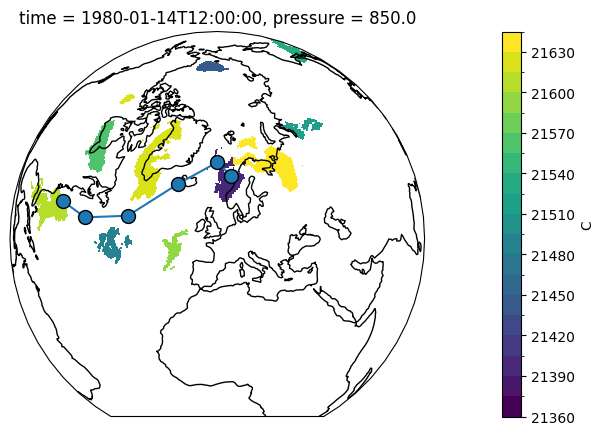

In [48]:
time= '1980-01-14T12:00:00'
plot = ds.C.sel(time=time).plot(subplot_kws=dict(projection = ccrs.Orthographic(0,50)), transform=ccrs.PlateCarree(), aspect=4, size=5, levels=25)

cyc_track = cycs.loc[cycs.track_id==21397].set_index('date').resample('D').mean()
# sns.scatterplot(cyc_track, x='lon', y='lat', hue='date',ax=plot.axes,transform=ccrs.PlateCarree())
plot.axes.plot(cyc_track.lon, cyc_track.lat, transform=ccrs.PlateCarree(), marker='o', markersize=10, markeredgecolor='0')
# cycs.loc[cycs.track_id==22502].plot(x='lon',y='lat', transform=ccrs.PlateCarree(), ax=plot.axes, lw=0, marker='o')
# cycs.loc[cycs.track_id==22439].plot(x='lon',y='lat', transform=ccrs.PlateCarree(), ax=plot.axes, lw=0, marker='o')


plot.axes.coastlines()

In [ ]:
import pandas as pd 
df_14['day'] = pd.to_datetime(df_14.time.dt.strftime("%Y-%m-%d"))
df_14.set_index('day').features.groupby('day').count

day
1980-01-04    127
1980-01-05     32
1980-01-12     56
1980-01-13    175
1980-01-14    136
1980-01-15      1
1980-01-16     50
1980-01-17     86
1980-01-18    108
1980-01-21      3
1980-01-22      1
1980-01-23      9
1980-01-25     33
1980-01-26     38
1980-01-27      6
1980-01-28      2
1980-01-29     28
1980-01-30     93
Name: features, dtype: int64

In [37]:
ds_rain.sel(time='1980-01').max().values

array(14.00268369)

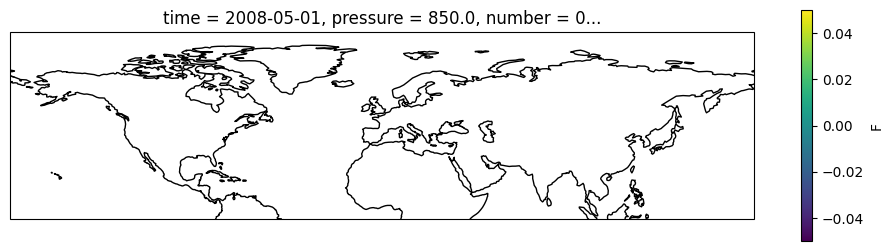

In [8]:
plot = ds.where(ds_regions==14).F.isel(time=0).plot(transform=ccrs.PlateCarree(), subplot_kws=dict(projection=ccrs.PlateCarree()), size=3, aspect=4)
plot.axes.coastlines()